In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [2]:
np.random.seed(42)

In [3]:
train_data = pd.read_csv("./data/nvda_train.csv", index_col="Date", parse_dates=True)
test_data = pd.read_csv("./data/nvda_test.csv", index_col="Date", parse_dates=True)

train_prices = train_data['Close'].values.reshape(-1, 1)
test_prices = test_data['Close'].values.reshape(-1, 1)

print(f"Training samples: {len(train_prices)}")
print(f"Testing samples: {len(test_prices)}")

Training samples: 2043
Testing samples: 511


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [5]:
def create_sequences(data, time_steps=30):
    X = []
    y = []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 60

X_train, y_train = create_sequences(scaled_train, time_steps)
X_test, y_test = create_sequences(scaled_test, time_steps)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1983, 60, 1)
X_test shape: (451, 60, 1)


In [6]:
model = Sequential()

model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mean_squared_error')

model.summary()

/Users/jikaewsi/miniforge3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0311 - val_loss: 0.9947
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0024 - val_loss: 0.5749
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0021 - val_loss: 0.7084
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0019 - val_loss: 0.7134
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0016 - val_loss: 0.7959
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0015 - val_loss: 0.9303
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0017 - val_loss: 0.9190
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0015 - val_loss: 1.0364
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0015 - val_loss: 0.9002
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0014 - val_loss: 0.8856
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0014 - val_loss: 0.9114
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0

In [8]:
predicted_scaled = model.predict(X_test)

predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


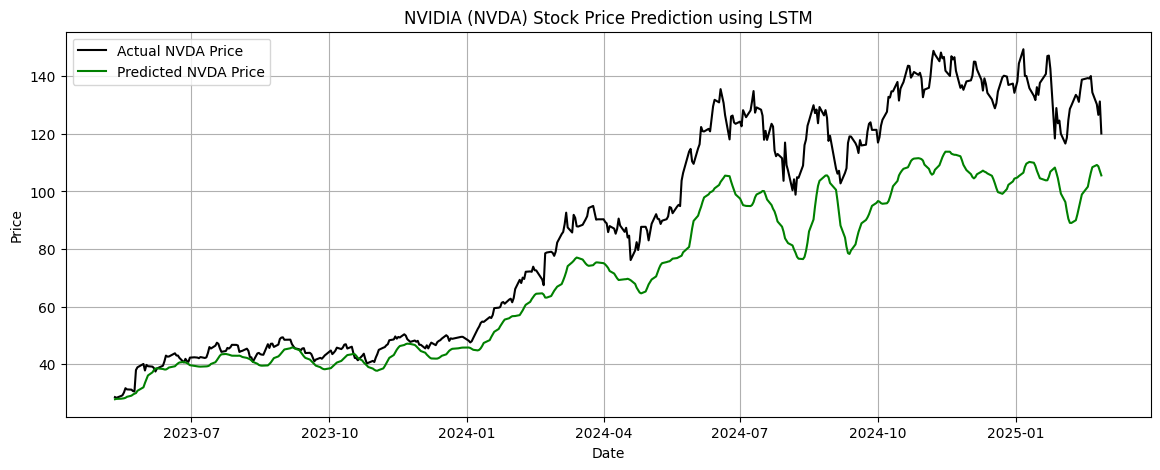

In [9]:
# Align the dates for plotting (skipping the first 'time_steps' days in the test set)
test_dates = test_data.index[time_steps:]

plt.figure(figsize=(14,5))
plt.plot(test_dates, actual_prices, color='black', label='Actual NVDA Price')
plt.plot(test_dates, predicted_prices, color='green', label='Predicted NVDA Price')
plt.title('NVIDIA (NVDA) Stock Price Prediction using LSTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()